Good — I have everything I need from the notebook and your message. Let's go.

---

# Part B: Time-Domain vs Frequency-Domain

---

## What are we even talking about?

Your audio file is a list of 48,000 numbers. That's the **time-domain** representation — raw pressure samples over time.

But here's the problem: if I give you `[0.002, -0.001, 0.008, ...]` and ask "is there a vowel here?", it's nearly impossible to tell. The raw numbers don't directly reveal *what frequencies are present* — and speech is fundamentally about frequency content. A vowel "aah" has energy at different frequencies than a consonant "sss".

So we have two fundamentally different ways to look at audio:

``` t
TIME-DOMAIN:           FREQUENCY-DOMAIN:
[0.002, -0.001, ...]   [[energy at 100Hz], [energy at 200Hz], ...]
     ↑                          ↑
"what happened                "what frequencies were
  at each moment"               present at each moment"
```

Neither is "better" — they contain the same information, just organized differently. Your choice of representation determines what patterns your neural network can easily learn.

---

## The Time-Domain View

This is literally the `.wav` file. Each number is the amplitude of the audio signal at one moment in time. At 16kHz, you have 16,000 numbers per second.

**What's easy to see in time-domain:**
- When someone starts/stops speaking (energy level changes)
- Silence vs speech
- The rough rhythm of speech

**What's hard to see:**
- Which vowel is being spoken
- Speaker identity (voice quality = frequency content)
- Whether there's noise at a specific pitch

**Who uses it:** Conv-TasNet operates directly on the raw waveform. It learns its own feature extraction via Conv1D — instead of you handcrafting features, the network figures out what frequency-like patterns to look for.

---

## The Frequency-Domain View: STFT

The **Short-Time Fourier Transform (STFT)** answers one question:

> "At this moment in time, which frequencies are present and how strong are they?"

But "this moment" is actually a small window — you can't analyze a single sample for frequency content, you need a short chunk. So STFT works like this:

1. Take a small window of samples (e.g., 400 samples = 25ms)
2. Apply Fourier Transform to that window → get frequency content
3. Slide the window forward by a hop length (e.g., 160 samples = 10ms)
4. Repeat until the whole signal is processed

The result is a **2D grid**: time on one axis, frequency on the other. Each cell contains "how much energy is at frequency F at time T". This is called a **spectrogram**.

``` t
Frequency
    ↑
4000|  ░░░▓▓▓░░░▓▓▓░░░
2000|  ░▓▓▓▓▓▓░▓▓▓▓▓▓░
1000|  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
 500|  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    +─────────────────→ Time
```

Now you can see speech structure visually. Vowels appear as horizontal bands (formants). Silence is dark. Consonants like "s" show high-frequency energy.

---

## Mel-Scale: Making It Perceptual

Here's a problem with the raw STFT: humans don't perceive frequency linearly. The difference between 100Hz and 200Hz sounds much bigger to your ears than the difference between 5000Hz and 5100Hz — even though both are 100Hz apart.

The **mel scale** compresses high frequencies and expands low frequencies to match human perception. Instead of 257 evenly-spaced frequency bins (from a standard STFT), you use ~80 **mel filterbanks** — triangular filters that are densely packed at low frequencies and sparsely packed at high frequencies.

``` t
Linear scale:  |--|--|--|--|--|--|--|--|--|--|  (equal spacing)
Mel scale:     |-|-|-|--|--|---|----|----|---| (compressed at top)
```

The result is a **mel-spectrogram**: same 2D time×frequency grid, but frequency axis is perceptually scaled. This is a much more compact and speech-relevant representation.

---

## Log-Mel-Filterbank (LMF)

One more step: you take the **log** of the mel-spectrogram energies. Why?

Because speech energy spans many orders of magnitude — quiet sounds might have energy 0.0001 and loud sounds 10.0. If you feed raw energies to a neural network, the loud sounds completely dominate. Taking the log compresses this range and makes training much more stable.

``` python
LMF = log(mel_filterbank_energies)
```

This is what **EEND uses** as its input. The standard configuration:
- 80 mel bins (frequency axis)
- Frame length: 25ms window
- Hop length: 10ms
- Result shape per 3-second clip: `(80, 300)` — 80 frequency bins × 300 time frames

---

## When to Use Which

| | Time-Domain | Frequency-Domain (LMF) |
|---|---|---|
| **What you give the network** | Raw waveform `(1, 48000)` | LMF features `(80, 300)` |
| **Who processes features** | Network learns them | You extract them manually |
| **Good for** | Separation, synthesis | Recognition, diarization |
| **Used by** | Conv-TasNet | EEND |
| **Downside** | Hard optimization, needs big models | Loses some phase information |

**Your EEND system will use LMF.** Conv-TasNet (which you'll build later) will use raw waveforms.

---

## How STFT Actually Works (Conceptually)

You don't need to implement Fourier Transforms from scratch — `torchaudio` handles this. But you should understand the key parameters:

- **`n_fft`** — size of the FFT window in samples. Larger = better frequency resolution, worse time resolution. Typically 400 (25ms).
- **`hop_length`** — how many samples to slide between windows. Typically 160 (10ms).
- **`n_mels`** — how many mel filterbanks. Typically 80.

These three numbers control the entire shape of your feature tensor.

---

## TODOs

Three TODOs this time — each builds on the last.

---

### TODO 1: Visualize a Spectrogram From Your Audio

**Goal:** Compute and visualize an STFT spectrogram from one of your `.wav` files. See speech structure with your own eyes.

**Requirements:**
- Load one audio file from your dataset
- Use `torchaudio.transforms.Spectrogram` to compute the STFT magnitude
- Plot the result as a 2D image using `plt.imshow` — time on x-axis, frequency on y-axis
- Make sure the colormap shows bright = high energy

**Hints:**
- `torchaudio.transforms.Spectrogram(n_fft=400, hop_length=160)` gives you a good starting point
- The output shape will be `(1, freq_bins, time_frames)` — you'll need to squeeze it for plotting
- Use `plt.colorbar()` to show the energy scale
- Try `aspect='auto'` in imshow so it doesn't squash into a square

**Expected output:** A 2D heatmap. You should see some structure — bright horizontal bands where vowels are, dark regions for silence, maybe vertical lines for consonant bursts.

**Key question:** What is the shape of your spectrogram tensor? How does it relate to `n_fft` and `hop_length`?

---

### TODO 2: Extract Log-Mel-Filterbank Features

**Goal:** Compute the actual LMF features that EEND uses. Compare the shape and appearance to the raw spectrogram.

**Requirements:**
- Using the same audio file, compute a **mel-spectrogram** with 80 mel bins
- Apply log (add a small epsilon first so you don't take log(0))
- Plot the result — it should look "smoother" than the raw spectrogram
- Print the output tensor shape

**Hints:**
- `torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_fft=400, hop_length=160, n_mels=80)` is what you want
- To apply log: `torch.log(mel_spec + 1e-8)` — the `1e-8` prevents log(0)
- The shape should be `(1, 80, 300)` for a 3-second clip at 16kHz

**After it works:**
- Try `n_mels=40` vs `n_mels=80` vs `n_mels=128` — what changes visually and in shape?
- Try `hop_length=80` vs `hop_length=160` vs `hop_length=320` — what changes?

**Key question:** Your current hand-crafted features are shape `(5,)`. Your LMF features are shape `(80, 300)`. That's 24,000 numbers vs 5. What implications does this have for your model architecture?

---

### TODO 3: Update Your Dataset to Use LMF Features

**Goal:** Replace the hand-crafted features in your `SpeakerDataset` with LMF features and train a model on them. This is the real test — do better features lead to better accuracy?

**Requirements:**
- Modify `SpeakerDataset.__getitem__` to return LMF features instead of the current 5 hand-crafted features
- The returned feature tensor should be shape `(80, 300)` — treat it like a 2D "image" of the audio
- Update your model to accept this input shape — you'll need a 2D flattening step or use `nn.Flatten` before your linear layers
- Train for enough epochs to see convergence (use early stopping)
- Compare final accuracy with your baseline (~52%)

**Hints:**
- Define the `MelSpectrogram` transform once, outside `__getitem__`, so you're not recreating it every call — put it in `__init__`
- Your model input is now `(batch, 80, 300)` — that's 24,000 features. You'll need to flatten it: `x = x.view(x.size(0), -1)` before the linear layer
- Start with a simple architecture: `Flatten → Linear(80*300, 128) → ReLU → Linear(128, 3)`
- Watch out: 24,000 inputs to a linear layer means a lot of parameters. Consider if this is reasonable.

**Key question after training:** Did LMF beat hand-crafted features? If not, why might that be? (Think about what 5 hand-crafted features capture vs what LMF captures)

---

Start with TODO 1. Show me the spectrogram and tell me what you see.

In [398]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchaudio.transforms as T
import math
from pathlib import Path
import os
import sys
import json
import matplotlib.pyplot as plt

# Check if __file__ exists (it won't in Jupyter)
try:
    current_dir = Path(__file__).parent
except NameError:
    # If in Jupyter, use the current working directory
    current_dir = Path(os.getcwd())

# Add project root to Python path
project_root = current_dir.parent.parent.parent
sys.path.insert(0, str(project_root))

from src.preprocessing.audio_utils import load_audio


# Device configuration (for your MacBook)
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✅ Using Apple Silicon GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("✅ Using NVIDIA GPU")
else:
    device = torch.device('cpu')
    print("⚠️ Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


✅ Using Apple Silicon GPU
PyTorch version: 2.10.0
Device: mps


In [399]:
class SpeakerDataset(torch.utils.data.Dataset):
    def __init__(self, manifest_path, limit=None):
        # Load manifest JSON
        # Store all entries as self.data
        with open(manifest_path, "r") as f:
            full_data = json.load(f)
        
        if limit:
            self.data = full_data[:limit]
        else:
            self.data = full_data
    
    def __len__(self):
        # Return number of samples
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get entry at index idx
        # Load audio from disk
        # Extract features
        # Get label (num_speakers - 1)
        # Return (features, label)
        entry = self.data[idx]
        mixture_path = Path(entry['mixture_path'])
        mixture_audio, _ = load_audio(mixture_path)
        mixture_tensor = torch.from_numpy(mixture_audio)
        
        max_len = 48000
        
        if mixture_tensor.size(0) > max_len:
            # Truncate if too long
            mixture_tensor = mixture_tensor[:max_len]
        else:
            # Pad with zeros if too short
            padding = max_len - mixture_tensor.size(0)
            mixture_tensor = torch.nn.functional.pad(mixture_tensor, (0, padding))
        
        mixture_tensor = mixture_tensor.unsqueeze(0)
        
        speaker_count = int(entry['num_speakers']) - 1
        label_tensor = torch.tensor(speaker_count, dtype=torch.long)
        
        return mixture_tensor, label_tensor

In [400]:
train_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "train" / "train_manifest.json"
train_dataset = SpeakerDataset(train_manifest_path)
print(len(train_dataset))

val_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "val" / "val_manifest.json"
val_dataset = SpeakerDataset(val_manifest_path, 2000)
print(len(val_dataset))

10000
2000


In [401]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

In [402]:
audio = train_dataset[0][0][0]

### todo 1

In [403]:
spectrogram_transform = T.Spectrogram(n_fft=400, hop_length=160)

spec = spectrogram_transform(audio)

print(f"Waveform shape: {audio.shape}") # [channels, time]
print(f"Spectrogram shape: {spec.shape}")  # [channels, freq, time]

Waveform shape: torch.Size([48000])
Spectrogram shape: torch.Size([201, 301])


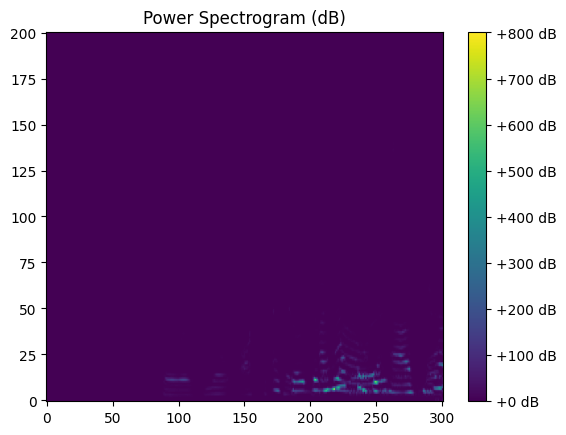

In [404]:
plt.imshow(spec.numpy(), origin='lower', aspect='auto')
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram (dB)")
plt.show()

### todo 2

In [405]:
melspectrogram_transform = T.MelSpectrogram(sample_rate=16000, n_fft=400, hop_length=160, n_mels=40)

melspec = melspectrogram_transform(audio)
melspec = torch.log(melspec + 1e-8)

print(f"Waveform shape: {audio.shape}") # [channels, time]
print(f"Log-Mel-Filterbank shape: {melspec.shape}")  # [channels, freq, time]

Waveform shape: torch.Size([48000])
Log-Mel-Filterbank shape: torch.Size([40, 301])


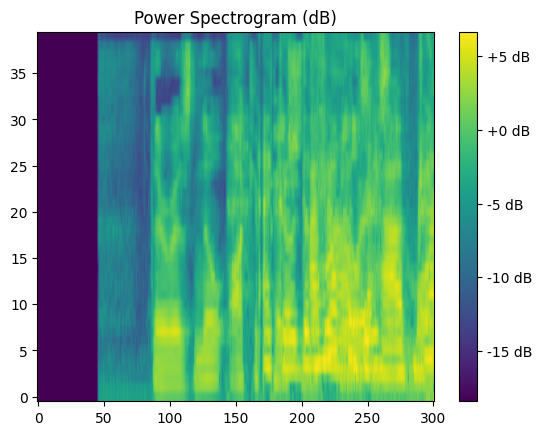

In [406]:
img_data = melspec.squeeze().detach().cpu().numpy()

plt.imshow(img_data, origin='lower', aspect='auto')
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram (dB)")
plt.show()

for n_mels = 40
Waveform shape: torch.Size([48000])
Log-Mel-Filterbank shape: torch.Size([40, 301])

for n_mels = 80
Waveform shape: torch.Size([48000])
Log-Mel-Filterbank shape: torch.Size([80, 301])

for n_mels = 128
Waveform shape: torch.Size([48000])
Log-Mel-Filterbank shape: torch.Size([128, 301])



/Users/apple/Documents/programing/projects/voice_isolation/.venv/lib/python3.10/site-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


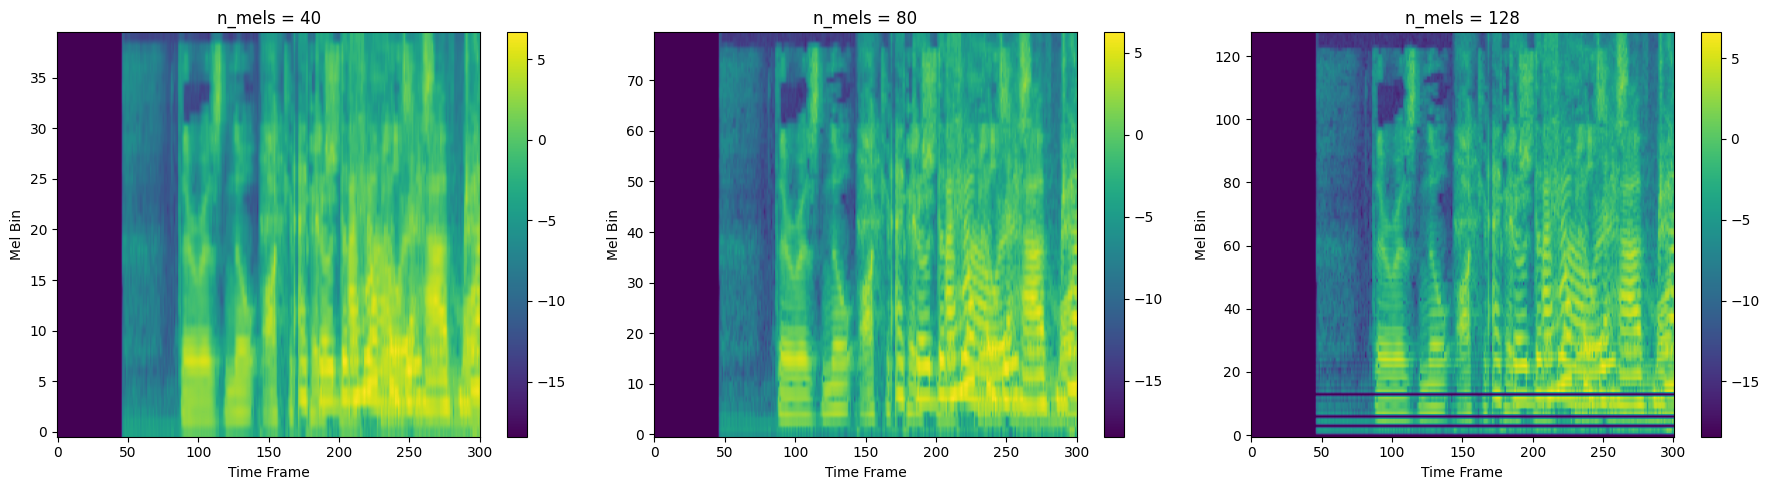

In [407]:
# List of n_mels to iterate through
n_mels_list = [40, 80, 128]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, n_mels in enumerate(n_mels_list):
    # 1. Define and apply transform
    transform = T.MelSpectrogram(
        sample_rate=16000, 
        n_fft=400, 
        hop_length=160, 
        n_mels=n_mels
    )
    melspec = transform(audio)
    
    # 2. Apply log scaling (Your manual method)
    log_melspec = torch.log(melspec + 1e-8)
    
    # 3. Print statements as requested
    print(f"for n_mels = {n_mels}")
    print(f"Waveform shape: {audio.shape}")
    print(f"Log-Mel-Filterbank shape: {log_melspec.shape}\n")
    
    # 4. Prepare for plotting (Squeeze and move to CPU)
    # We use .squeeze() to handle the [1, freq, time] shape
    img_data = log_melspec.squeeze().detach().cpu().numpy()
    
    # 5. Plot on the specific subplot axis
    im = axes[i].imshow(img_data, origin='lower', aspect='auto', cmap='viridis')
    axes[i].set_title(f"n_mels = {n_mels}")
    axes[i].set_ylabel("Mel Bin")
    axes[i].set_xlabel("Time Frame")
    
    # Optional: Add a colorbar to each to show intensity scale
    fig.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

for n_mels = 128
Waveform shape: torch.Size([48000])
Log-Mel-Filterbank shape: torch.Size([40, 1201])

for n_mels = 128
Waveform shape: torch.Size([48000])
Log-Mel-Filterbank shape: torch.Size([40, 601])

for n_mels = 128
Waveform shape: torch.Size([48000])
Log-Mel-Filterbank shape: torch.Size([40, 376])



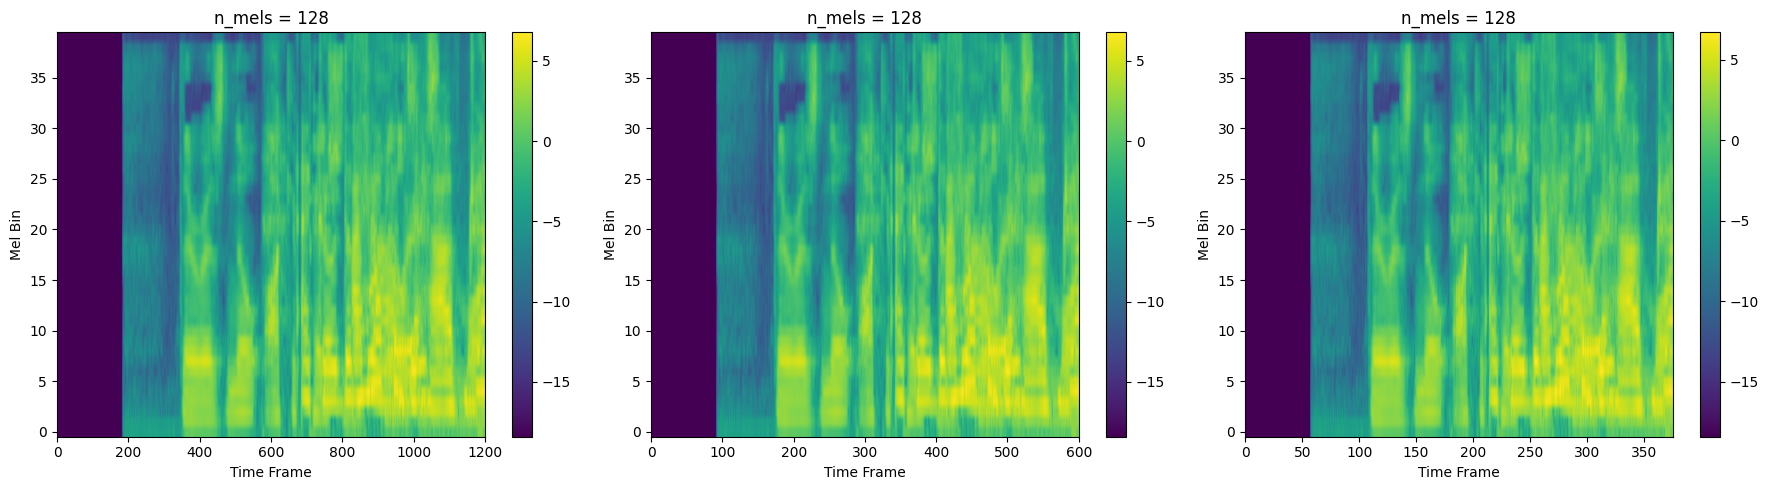

In [408]:
# List of n_mels to iterate through
hop_length_list = [80,160,320]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, hop_length in enumerate(n_mels_list):
    # 1. Define and apply transform
    transform = T.MelSpectrogram(
        sample_rate=16000, 
        n_fft=400, 
        hop_length=hop_length, 
        n_mels=40
    )
    melspec = transform(audio)
    
    # 2. Apply log scaling (Your manual method)
    log_melspec = torch.log(melspec + 1e-8)
    
    # 3. Print statements as requested
    print(f"for n_mels = {n_mels}")
    print(f"Waveform shape: {audio.shape}")
    print(f"Log-Mel-Filterbank shape: {log_melspec.shape}\n")
    
    # 4. Prepare for plotting (Squeeze and move to CPU)
    # We use .squeeze() to handle the [1, freq, time] shape
    img_data = log_melspec.squeeze().detach().cpu().numpy()
    
    # 5. Plot on the specific subplot axis
    im = axes[i].imshow(img_data, origin='lower', aspect='auto', cmap='viridis')
    axes[i].set_title(f"n_mels = {n_mels}")
    axes[i].set_ylabel("Mel Bin")
    axes[i].set_xlabel("Time Frame")
    
    # Optional: Add a colorbar to each to show intensity scale
    fig.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

# todo 3

In [409]:
class LogMelSpeakerDataset(torch.utils.data.Dataset):
    def __init__(self, manifest_path, limit=None):
        # Load manifest JSON
        # Store all entries as self.data
        with open(manifest_path, "r") as f:
            full_data = json.load(f)
        
        if limit:
            self.data = full_data[:limit]
        else:
            self.data = full_data
        
        self.transform = T.MelSpectrogram(
        sample_rate=16000, 
        n_fft=400, 
        hop_length=160, 
        n_mels=80
        )
    
    def __len__(self):
        # Return number of samples
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get entry at index idx
        # Load audio from disk
        # Extract features
        # Get label (num_speakers - 1)
        # Return (features, label)
        entry = self.data[idx]
        mixture_path = Path(entry['mixture_path'])
        mixture_audio, _ = load_audio(mixture_path)
        mixture_tensor = torch.from_numpy(mixture_audio)
        
        max_len = 480000
        
        if mixture_tensor.size(0) > max_len:
            # Truncate if too long
            mixture_tensor = mixture_tensor[:max_len]
        else:
            # Pad with zeros if too short
            padding = max_len - mixture_tensor.size(0)
            mixture_tensor = torch.nn.functional.pad(mixture_tensor, (0, padding))
        
        melspec = self.transform(mixture_tensor)
        
        # 2. Apply log scaling (Your manual method)
        log_melspec = torch.log(melspec + 1e-8)
        
        
        speaker_count = int(entry['num_speakers']) - 1
        label_tensor = torch.tensor(speaker_count, dtype=torch.long)
        
        return log_melspec, label_tensor

In [410]:
train_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "train" / "train_manifest.json"
logmel_train_dataset = LogMelSpeakerDataset(train_manifest_path)
print(len(logmel_train_dataset))

val_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "val" / "val_manifest.json"
logmel_val_dataset = LogMelSpeakerDataset(val_manifest_path, 2000)
print(len(logmel_val_dataset))

10000
2000


In [411]:
logmel_train_loader = DataLoader(
    dataset=logmel_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

logmel_val_loader = DataLoader(
    dataset=logmel_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

In [412]:
class SpeakerCounter(nn.Module):
    """
    Classifier that predicts number of speakers (1, 2, or 3)
    from audio features.
    """
    def __init__(self, input_size=24080, hidden_sizes=[128, 64, 32], num_classes=3):
        super().__init__()
        # TODO: Build network with given architecture
        # Hint: Use nn.Sequential or define layers individually
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.BatchNorm1d(hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_sizes[0],hidden_sizes[1]),
            nn.BatchNorm1d(hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_sizes[1],hidden_sizes[2]),
            nn.BatchNorm1d(hidden_sizes[2]),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_sizes[2],num_classes)
        )
        
    def forward(self, x):
        # TODO: Implement forward pass
        x = x.view(x.size(0), -1)
        return self.network(x)

In [413]:
class EarlyStopping:
    def __init__(self, patience, min_delta):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.should_stop = False
    
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.counter = 0
            self.best_loss = val_loss
            self.should_stop = False # improvement 
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            else: 
                self.should_stop = False
        
        return self.should_stop

In [414]:
def compute_accuracy(predictions, labels):
    """
    predictions: (batch_size, 3) logits
    labels: (batch_size,) true classes
    
    Returns: accuracy as percentage
    """
    predicted_classes = torch.argmax(predictions, dim=1)
    correct = (predicted_classes == labels).sum().item()
    total = labels.size(0)
    return 100.0 * correct / total

In [415]:
def train_with_optimizer(optimizer_name="sgd", num_epochs=5):
    
    a,b = logmel_train_dataset[0][0].shape
    model = SpeakerCounter(input_size=a*b).to(device)
    
    if optimizer_name=="sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
    elif optimizer_name=="adam":
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
    elif optimizer_name=="adamw":
        optimizer = optim.AdamW(model.parameters(), lr=0.0001)
    
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, min_lr=1e-6)
    early_stop = EarlyStopping(patience=5, min_delta=0.001)
    
    output = {
        'train_losses': [], 
        'val_losses': [], 
        'train_accs': [], 
        'val_accs': []
    }
    
    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} Summary ---")
        model.train()
        running_train_loss = 0.0
        running_train_acc = 0.0
        steps_per_epoch_train = len(logmel_train_loader)
        
        for step, batch in enumerate(logmel_train_loader):
            features, labels = batch[0].to(device), batch[1].to(device)
            
            # Forward pass
            logits = model(features)  
            
            # Compute loss
            loss = F.cross_entropy(logits, labels)
            
            # Backward pass
            loss.backward()
            
            # Update weights
            optimizer.step()
            optimizer.zero_grad()
            
            # Compute accuracy
            running_train_loss += loss.item() 
            running_train_acc += compute_accuracy(logits, labels)
            
            # Optional: Print batch progress every 50 batches within the epoch
            if (step + 1) % 50 == 0:
                print(f"  train Batch {step+1}/{steps_per_epoch_train} | Loss: {loss.item():.4f}")
        
        # 3. Print Summary at the end of each FULL epoch
        avg_train_loss = running_train_loss / steps_per_epoch_train
        avg_train_acc = running_train_acc / steps_per_epoch_train    
        
        model.eval()
        running_val_loss = 0.0
        running_val_acc = 0.0     
        steps_per_epoch_val = len(logmel_val_loader)
        
        with torch.no_grad():
            for steps, batch in enumerate(logmel_val_loader):
                
                features, labels = batch[0].to(device), batch[1].to(device)
                
                # Forward pass
                logits = model(features)  
                
                # Compute loss
                loss = F.cross_entropy(logits, labels)
                
                # number of correct class
                running_val_loss += loss.item()
                running_val_acc += compute_accuracy(logits, labels)
                
                # Optional: Print batch progress every 50 batches within the epoch
                if (steps + 1) % 30 == 0:
                    print(f"  val Batch {steps+1}/{steps_per_epoch_val} | Loss: {loss.item():.4f}")
        
        # Calculate Averages
        avg_val_loss = running_val_loss / steps_per_epoch_val
        avg_val_acc = running_val_acc / steps_per_epoch_val   
        
        # --- LOGGING & SCHEDULER ---
        print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
        print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%")
        
        scheduler.step(avg_val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr}\n")
        
        output['train_losses'].append(avg_train_loss)
        output['val_losses'].append(avg_val_loss)
        output['train_accs'].append(avg_train_acc)
        output['val_accs'].append(avg_val_acc)
        
        if early_stop(avg_val_loss):
            print("Early stopping triggered")
            print(f"triggered at epoch: {epoch}")
            print(f"best val loss achieved: {early_stop.best_loss:.6f}")
            break
    
    return output, model

In [416]:
output, model = train_with_optimizer("adamw", 50)


--- Epoch 1/50 Summary ---
  train Batch 50/312 | Loss: 0.9458
  train Batch 100/312 | Loss: 0.8630
  train Batch 150/312 | Loss: 0.8646
  train Batch 200/312 | Loss: 0.7618
  train Batch 250/312 | Loss: 0.6892
  train Batch 300/312 | Loss: 0.7515
  val Batch 30/63 | Loss: 0.9621
  val Batch 60/63 | Loss: 0.6411
Train Loss: 0.7637 | Train Acc: 72.33%
Val Loss:   0.7370 | Val Acc:   72.17%
Current Learning Rate: 0.0001


--- Epoch 2/50 Summary ---
  train Batch 50/312 | Loss: 0.5563
  train Batch 100/312 | Loss: 0.5900
  train Batch 150/312 | Loss: 0.5555
  train Batch 200/312 | Loss: 0.6779
  train Batch 250/312 | Loss: 0.6882
  train Batch 300/312 | Loss: 0.7210
  val Batch 30/63 | Loss: 0.9260
  val Batch 60/63 | Loss: 0.5733
Train Loss: 0.5865 | Train Acc: 79.25%
Val Loss:   0.6596 | Val Acc:   74.60%
Current Learning Rate: 0.0001


--- Epoch 3/50 Summary ---
  train Batch 50/312 | Loss: 0.4445
  train Batch 100/312 | Loss: 0.4215
  train Batch 150/312 | Loss: 0.4666
  train Batch 